# Interpreting Chemprop Predictions with Myerson Values

[Myerson values](https://doi.org/10.1007%2F978-3-540-24790-6_2) are a solution concept similar to the Shapley value from cooperative game theory. By treating a graph neural network (such as chemprops MPNN) as the payoff function of a game, we can assign each player of the game (each node in a graph) its contribution to the payoff, i.e. its contribution to the final prediction.

The [`myerson`](https://myerson.readthedocs.io) python package can be used to calculate Myerson values or approximate them using Monte Carlo sampling (as the calculation times become infeasible for larger graphs).

We'll have a look at a toy example in this notebook, to see if a model is able to recognize a hydroxy group.

In [1]:
# imports
import lightning.pytorch as pl
from chemprop import data, models, nn
from rdkit import Chem
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

from myerson.chemprop_explain import MyersonExplainer, MyersonSamplingExplainer


In [ ]:
# create dummy data (find hydroxy groups)
smiles = ['c1ccccc1O', 'Cc1ccccc1O', 'CCc1ccccc1O', 'CCCc1ccccc1O', 'Cc1c(C)cccc1O',
 'c1ccccc1', 'Cc1ccccc1', 'CCc1ccccc1', 'CCCc1ccccc1', 'Cc1c(C)cccc1']
labels = [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]
all_data = data.MoleculeDataset([data.MoleculeDatapoint.from_smi(smi, [y]) for smi, y in zip(smiles, labels)])
train_loader = data.build_dataloader(all_data, shuffle=False)

# train model 
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
ffn = nn.RegressionFFN()
model = models.MPNN(mp, agg, ffn)
print('model instantiated')
trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False,
    max_epochs=50, # intentional overfit
    # callbacks=[] # here we could also add callbacks
)
trainer.fit(model, train_loader)
predictions = trainer.predict(model, train_loader) # with the callback we would get the explanations


prediction=0.9790
my_values=
[ 0.03268035 -0.13644482 -0.19691372 -0.13644481  0.03268035  0.57113864
  0.81226023]
sum(my_values)=0.9790


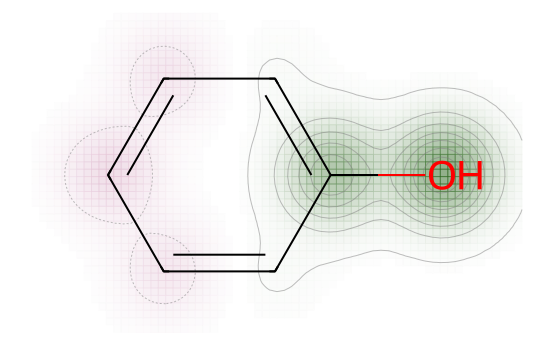

In [ ]:
# helper function to draw the explanations as heatmaps
def draw_myerson_values(smiles, myerson_values):
    mol = Chem.MolFromSmiles(smiles)
    d2d = Draw.MolDraw2DSVG(550,350)
    SimilarityMaps.GetSimilarityMapFromWeights(mol, list(myerson_values), d2d)
    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

graph = all_data[0].mg
explainer = MyersonExplainer(graph, model)           # you can also use the MyersonSamplingExplainer
my_values = explainer.calculate_all_myerson_values() # in that case call `sample_all_myerson_values`
print(f"prediction={explainer.calculate_prediction():.4f}")
print(f"my_values=\n{my_values}")
print(f"sum(my_values)={sum(my_values):.4f}")
draw_myerson_values(smiles[0], my_values)

We see that the Myerson values add up to the total prediction. For this prediction, the model learned that the not only the oxygen atom contributes, but also the connected carbon atom.
> **⚠️ Warning**
> The `MyersonCalculator` should only be used with Molecules with up to 20 (non-hydrogen) atoms. A handful of atoms more should be fine but will already take longer and at a certain point the program will run out of memory. Use the `MyersonSampler` in these cases.

Note that `myerson.chemprop` also contains explainer for multilabel predictive models: `MyersonClassExplainer` and `MyersonSamplingClassExplainer`. There is also the `--callback myerson` flag which you can use with the `predict` subcommand to calculate explanations for the predictions directly from the command line.  